# Simple functions for ground and excited states

## Example: the electronic states of molecular oxygen

This example notebook shows how to determine active spaces for the triplet ground state of oxygen, and its lowest excited singlet states. An emphasis is placed on simple wrapper functions to determine active spaces directly from a molecule definition.

The following learning points are covered:

- Selecting an active space using a simple wrapper function.
- Selecting an active space using a wrapper function for multiple electronic states.
- Using the selected active space in CASSCF calculations, including an example with state averaging.
- Using suitable wrapper functions to choose active spaces of a specific size defined by the user.

In [1]:
# Suppress PySCF warning...
import pyscf
pyscf.__config__.B3LYP_WITH_VWN5 = False

In [2]:
from pathlib import Path

# The Mole class is used to define molecular information in PySCF.
from pyscf.gto import Mole

# logger contains definitions of verbosity levels for PySCF.
from pyscf.lib import logger

# Functionality for (state-averaged) CASSCF.
from pyscf.mcscf import CASSCF, state_average_mix
from pyscf.fci.direct_spin1 import FCISolver
from pyscf.fci.addons import fix_spin

# Wrapper functions to perform selection for variable and fixed active space sizes
from asf.wrapper import find_from_mol, find_from_scf, sized_space_from_mol, sized_space_from_scf

# Various utility functions...
from asf.utility import compare_active_spaces, show_mos_grid, pictures_Jmol

There are two variants of the wrapper function to find general active spaces: `find_from_mol` and `find_from_scf`. The former accepts a `Mole` objects containing a molecular definition and performs the entire active space selection, including an SCF calculation. It is usually performed as a UHF calculation even if the molecule does not have any unpaired electrons. Stability analysis is used to help the UHF calculation converge to a broken-symmetry solution, which helps with the initial active space selection. It is also possible to start from a converged RHF or UHF solution directly using `find_from_scf`, which carries out the same steps as `find_from_mol` with the exception of the SCF calculation itself.

In [3]:
help(find_from_mol)

Help on function find_from_mol in module asf.wrapper:

find_from_mol(mol: pyscf.gto.mole.Mole, max_norb: Optional[int] = None, min_norb: Optional[int] = None, entropy_threshold: float = 0.13862943611198905, max_scf_restarts: int = 5, scf_kwargs: Optional[dict[str, Any]] = None, verbose: bool = True, **kwargs) -> asf.asfbase.ActiveSpace
    Select an active space with an entropy threshold, starting from a Molecule.
    
    This function attempts to calculate a stable UHF solution for the Mole object provided.
    Subsequently, find_from_scf(...) is called to calculate MP2 natural orbitals, and to
    select an active space from those.
    
    For more details, please refer to find_from_scf(...).
    
    Args:
        mol:                Mole instance containing the molecular data.
        max_norb:           Maximum number of active orbitals per root.
        min_norb:           Minimum number of active orbitals per root.
        entropy_threshold:  Entropy threshold to select a sing

In [4]:
help(find_from_scf)

Help on function find_from_scf in module asf.wrapper:

find_from_scf(mf: pyscf.scf.hf.SCF, max_norb: Optional[int] = None, min_norb: Optional[int] = None, entropy_threshold: float = 0.13862943611198905, states: Union[int, list[tuple[int, int]], NoneType] = None, sort_mos: bool = False, mp2_kwargs: Optional[dict[str, Any]] = None, switch_dmrg: int = 12, dmrg_kwargs: Optional[dict[str, Any]] = None, fci_kwargs: Optional[dict[str, Any]] = None, verbose: bool = True, ci_nroots: int = 1) -> asf.asfbase.ActiveSpace
    Select an active space with an entropy threshold, starting from an SCF calculation.
    
    The function executes the following steps:
        1)  Calculate MP2 natural orbitals using the SCF object provided in the input.
        2)  Select an initial set of MP2 natural orbitals based on their eigenvalues.
        3)  Perform a DMRGCI or CASCI calculation (depending on the number of active orbitals in
            the initial space) using the previously determined orbital subs

We start with a molecule definition of oxygen in its (triplet) ground state.

In [5]:
mol = Mole()
mol.atom = "O2.xyz"
mol.basis = "def2-SVP"
mol.charge = 0
mol.spin = 2
# Set mol.verbose = logger.INFO to enable printing of SCF iterations and further output.
mol.verbose = logger.NOTE
mol.build()

All that is required now for an active space selection is one function call:

In [6]:
active_space = find_from_mol(mol)


--------------------------------------------------------------------------------
Calculating UHF orbitals
--------------------------------------------------------------------------------

-> Initiating a UHF calculation.
converged SCF energy = -149.49029917455  <S^2> = 2.0338703  2S+1 = 3.0224958


<class 'pyscf.scf.uhf.UHF'> wavefunction is stable in the internal stability analysis


-> The calculated SCF solution is converged and stable.

--------------------------------------------------------------------------------
Calculating MP2 natural orbitals
--------------------------------------------------------------------------------




-> Selected initial orbital window of 12 electrons in 11 MP2 natural orbitals.

--------------------------------------------------------------------------------
Running calculation
--------------------------------------------------------------------------------

spin = 2, number of roots = 1
total number of roots calculated = 1



CASCI E = -149.643455130938  E(CI) = -47.2494800494851  S^2 = 2.0000000



Orbital selection for state 0:



 MO    w( )    w(↑)    w(↓)    w(⇅)       S  sel
  2   0.000   0.002   0.001   0.996   0.027     
  3   0.001   0.004   0.003   0.992   0.055     
  4   0.001   0.034   0.002   0.963   0.173    a
  5   0.001   0.034   0.002   0.963   0.173    a
  6   0.007   0.012   0.015   0.967   0.180    a
  7   0.004   0.963   0.004   0.030   0.180    a
  8   0.004   0.963   0.004   0.030   0.180    a
  9   0.964   0.017   0.011   0.008   0.192    a
 10   0.988   0.009   0.002   0.001   0.072     
 11   0.988   0.009   0.002   0.001   0.072     
 12   0.992   0.004   0.004   0.001   0.055     


--------------------------------------------------------------------------------
Active space selection finished
--------------------------------------------------------------------------------

-> Selected an active space of 8 electrons in 6 orbitals.


The returned object contains the number of active MOs and electrons, the matrix of MO coeffients and a list of active orbital indices referring to the aforementioned matrix.

In [7]:
print(active_space)

ActiveSpace: 8 electrons in 6 orbitals
  active MO indices: [4, 5, 6, 7, 8, 9]


Below, we plot the active orbitals that were found.

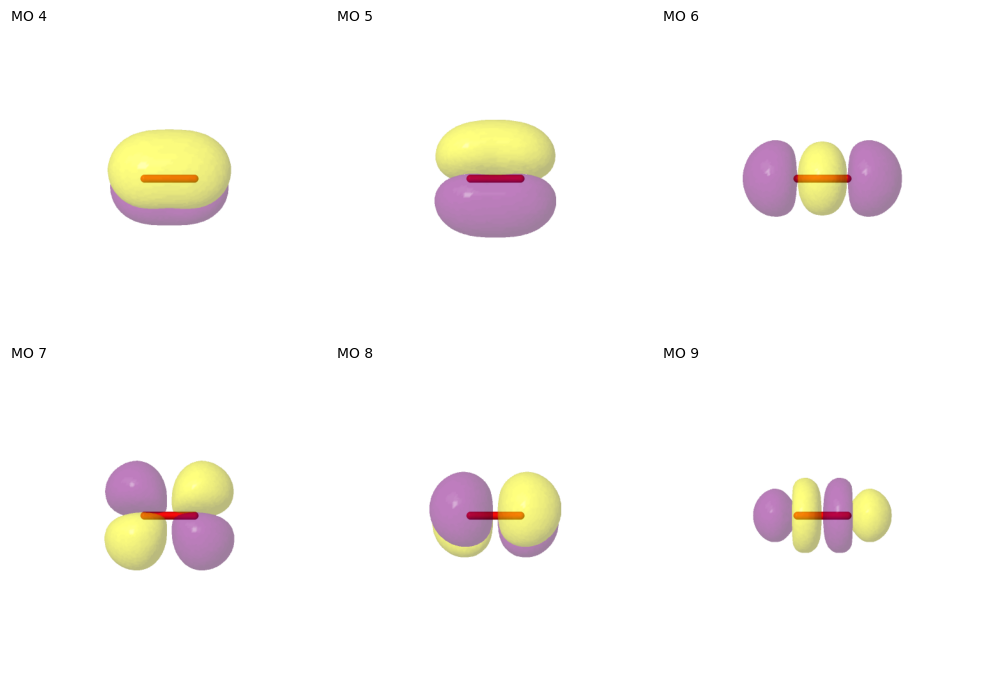

In [8]:
pictures_Jmol(
    mol=mol, mo_coeff=active_space.mo_coeff, mo_list=active_space.mo_list, mo_index_title=" "
)
mo_images = sorted(dd for dd in Path.cwd().glob("mo_*.png"))
show_mos_grid(mo_images, mo_list=active_space.mo_list, columns=3, figsize=(10, 10))
# clean up files
for filename in mo_images:
    Path.unlink(filename)

The selected active space can be used to set up a CASSCF calculation. Note that it is important to use the orbitals returned by the ASF in the object `active_space` - not the orbitals obtained from SCF or elsewhere!

In [9]:
mc = CASSCF(mol, ncas=active_space.norb, nelecas=active_space.nel)
# Before carrying out the CASSCF calculation, the orbital coefficient matrix columns need to be
# ordered as core - active - virtual from left to right.
# Take care - by default, sort_mo assumes that the MO list starts indexing from one, not from zero.
mo_guess = mc.sort_mo(active_space.mo_list, active_space.mo_coeff, base=0)
_ = mc.kernel(mo_coeff=mo_guess)

CASSCF energy = -149.570669531979


CASCI E = -149.570669531979  E(CI) = -21.8747875944703  S^2 = 2.0000000


A CASSCF calculation converging in a small number of iterations is often a good sign. In general, it is advisable to inspect converged CASSCF orbitals visually in order to verify that they indeed form the expected active space. In our case, that would mean comparing them to the guess orbitals determined by the active space finder.

Here, however, we will employ a simple numerical criterion by performing a singular value decomposition of the overlap matrix between the guess and the converged active orbitals. The following function reports the smallest singular value - if it is close to one, that is a good sign. A value close to zero indicates that an orbital may have rotated out, while intermediate values indicate some degree of mixing.

In [10]:
compare_active_spaces(mc, active_space.mo_coeff, active_space.mo_list)

0.9962126640630586

The functions `find_from_mol` / `find_from_scf` can also be employed to find active spaces for state-averaged CASSCF calculations of multiple electronic states. This functionality is relatively simple, determining active spaces for each electronic state in isolation, and then forming the union of the MO sets. States can be specified in one of two ways:

1. Using `states: int`. in that case, the active space will be determined for a number `states` of states with the multiplicity inferred from the Mole or SCF object.
2. Using `states: list[tuple[int, int]]`. the first integer in each tuple specifies the number of electrons (`spin` in PySCF conventions), the second integer the number of electronic states of that spin. In this case, the union is formed over the active spaces for all states of all spin multiplicities requested.
Below this will be demonstrated for one triplet and three singlet states of oxygen:

In [11]:
active_space = find_from_mol(mol, states=[(0, 3), (2, 1)])


--------------------------------------------------------------------------------
Calculating UHF orbitals
--------------------------------------------------------------------------------

-> Initiating a UHF calculation.
converged SCF energy = -149.49029917455  <S^2> = 2.0338703  2S+1 = 3.0224958


<class 'pyscf.scf.uhf.UHF'> wavefunction is stable in the internal stability analysis


-> The calculated SCF solution is converged and stable.

--------------------------------------------------------------------------------
Calculating MP2 natural orbitals
--------------------------------------------------------------------------------




-> Selected initial orbital window of 12 electrons in 11 MP2 natural orbitals.

--------------------------------------------------------------------------------
Running calculation
--------------------------------------------------------------------------------

spin = 0, number of roots = 3
total number of roots calculated = 3




WARN: Mulitple states found in CASCI solver. First state is used to compute the Fock matrix and natural orbitals in active space.



...

 MO    w( )    w(↑)    w(↓)    w(⇅)       S  sel
  2   0.000   0.001   0.001   0.997   0.025     
  3   0.001   0.003   0.003   0.994   0.045     
  4   0.016   0.013   0.013   0.959   0.217    a
  5   0.016   0.013   0.013   0.959   0.217    a
  6   0.007   0.012   0.012   0.969   0.170    a
  7   0.467   0.009   0.009   0.514   0.784    a
  8   0.467   0.009   0.009   0.514   0.784    a
  9   0.968   0.012   0.012   0.008   0.176    a
 10   0.990   0.004   0.004   0.001   0.063     
 11   0.990   0.004   0.004   0.001   0.063     
 12   0.993   0.003   0.003   0.001   0.051     


Orbital selection for state 2:



 MO    w( )    w(↑)    w(↓)    w(⇅)       S  sel
  2   0.001   0.002   0.002   0.995   0.040     
  3   0.006   0.003   0.003   0.987   0.083     
  4   0.028   0.006   0.006   0.959   0.204    a
  5   0.028   0.006   0.006   0.959   0.204    a
  6   0.008   0.012   0.012   0.969   0.173    a
  7   0.459   0.008   0.008   0.525   0.771    a
  8   0.459   0.008   0.008   0.525   0.771    a
  9   0.968   0.011   0.011   0.009   0.177    a
 10   0.991   0.004   0.004   0.001   0.058     
 11   0.991   0.004   0.004   0.001   0.058     
 12   0.992   0.003   0.003   0.001   0.052     


--------------------------------------------------------------------------------
Running calculation
--------------------------------------------------------------------------------

spin = 2, number of roots = 1
total number of roots calculated = 1



CASCI E = -149.643455131976  E(CI) = -47.2494800505225  S^2 = 2.0000000



Orbital selection for state 0:



 MO    w( )    w(↑)    w(↓)    w(⇅)       S  sel
  2   0.000   0.002   0.001   0.996   0.027     
  3   0.001   0.004   0.003   0.992   0.055     
  4   0.001   0.034   0.002   0.963   0.173    a
  5   0.001   0.034   0.002   0.963   0.173    a
  6   0.007   0.012   0.015   0.967   0.180    a
  7   0.004   0.963   0.004   0.030   0.180    a
  8   0.004   0.963   0.004   0.030   0.180    a
  9   0.964   0.017   0.011   0.008   0.192    a
 10   0.988   0.009   0.002   0.001   0.072     
 11   0.988   0.009   0.002   0.001   0.072     
 12   0.992   0.004   0.004   0.001   0.055     


--------------------------------------------------------------------------------
Active space selection finished
--------------------------------------------------------------------------------

-> Selected an active space of 8 electrons in 6 orbitals.


The recommended active space is the same as for triplet oxygen; note that the table printed by the wrapper can be inspected for the orbital occupations in each state.

Below, a state-averaged CASSCF calculation is performed with four states: the triplet, the two doubly degenerate lowest singlet states, and the third singlet state.

In [12]:
mc = CASSCF(mol, ncas=active_space.norb, nelecas=active_space.nel)
# The solvers for each spin need to be set up individually.
# See PySCF examples for state averages and state average mixes.
solver_t = FCISolver(mol)
solver_t.spin = 2
solver_s = FCISolver(mol)
solver_s.spin = 0
solver_s.nroots = 3
solver_s = fix_spin(solver_s, ss=0)
# All four states are weighted equally.
mc_mix = state_average_mix(mc, [solver_t, solver_s], weights=[0.25] * 4)
mo_guess = mc.sort_mo(active_space.mo_list, active_space.mo_coeff, base=0)
_ = mc_mix.kernel(mo_coeff=mo_guess)

CASSCF energy = -149.538540696944


CASCI E = -149.538540696944  E(CI) = -21.9089589659920  S^2 = 0.5000000


CASCI state-averaged energy = -149.538540696944


CASCI energy for each state


  State 0 weight 0.25  E = -149.570469313758 S^2 = 2.0000000


  State 1 weight 0.25  E = -149.537342839483 S^2 = 0.0000000


  State 2 weight 0.25  E = -149.537342839469 S^2 = 0.0000000


  State 3 weight 0.25  E = -149.509007795065 S^2 = 0.0000000


The main parameter controlling the size of the selected space is the entropy threshold, controlled via the parameter `entropy_threshold` of the `find_from_mol` and `find_from_scf` functions.

If you know the size of the desired active space and only need to select the correct orbitals, it is possible to do so via the functions `sized_space_from_mol` and `sized_space_from_scf`. The only difference between the two functions is that the former performs an SCF calculation, while the latter expects an object with an SCF solution as its input. These wrapper functions currently support only one electronic state at a time.

In [13]:
help(sized_space_from_mol)

Help on function sized_space_from_mol in module asf.wrapper:

sized_space_from_mol(mol: pyscf.gto.mole.Mole, size: Union[int, tuple[int, int]], max_scf_restarts: int = 5, scf_kwargs: Optional[dict[str, Any]] = None, verbose: bool = True, **kwargs) -> asf.asfbase.ActiveSpace
    Select an active space of certain size starting from a molecule.
    
    This function attempts to calculate a stable UHF solution for the Mole object provided.
    Subsequently, sized_space_from_scf(...) is called to calculate MP2 natural orbitals, and to
    select an active space from those.
    
    For more details, please refer to sized_space_from_scf(...).
    
    Args:
        mol:                Mole instance containing the molecular data.
        size:               Requested number of active orbitals M, or number of active electrons N
                            and number of active orbitals as a CAS tuple (N, M).
        max_scf_restarts:   Maximal number of times to restart when an unconverged or 

In [14]:
help(sized_space_from_scf)

Help on function sized_space_from_scf in module asf.wrapper:

sized_space_from_scf(mf: pyscf.scf.hf.SCF, size: Union[int, tuple[int, int]], state: Union[int, tuple[int, int], NoneType] = None, sort_mos: bool = False, mp2_kwargs: Optional[dict[str, Any]] = None, switch_dmrg: int = 12, dmrg_kwargs: Optional[dict[str, Any]] = None, fci_kwargs: Optional[dict[str, Any]] = None, verbose: bool = True, ci_nroots: int = 1) -> asf.asfbase.ActiveSpace
    Select an active space of certain size starting from an SCF calculation.
    
    The function executes the following steps:
        1)  Calculate MP2 natural orbitals using the SCF object provided in the input.
        2)  Select an initial set of MP2 natural orbitals based on their eigenvalues.
        3)  Perform a DMRGCI or CASCI calculation (depending on the number of active orbitals in
            the initial space) using the previously determined orbital subset.
        4)  Select the final active space based on the pair information.
    

It is possible to specify the size of an active space either via the number of orbitals by providing an integer, or by providing both the number of active electrons and orbitals as a tuple `(electrons, orbitals)`. If only the number of orbitals is provided, the number of electrons is determined by the active space finder.

For example, the following function call constrains the number of active orbitals to four and chooses an active space with a suitable number of electrons, resulting in a (6, 4) space:

In [15]:
sized_space_from_mol(mol, size=4)


--------------------------------------------------------------------------------
Calculating UHF orbitals
--------------------------------------------------------------------------------

-> Initiating a UHF calculation.
converged SCF energy = -149.49029917455  <S^2> = 2.0338703  2S+1 = 3.0224958


<class 'pyscf.scf.uhf.UHF'> wavefunction is stable in the internal stability analysis


-> The calculated SCF solution is converged and stable.

--------------------------------------------------------------------------------
Calculating MP2 natural orbitals
--------------------------------------------------------------------------------




-> Selected initial orbital window of 12 electrons in 11 MP2 natural orbitals.

--------------------------------------------------------------------------------
Running calculation
--------------------------------------------------------------------------------

spin = 2, requested root = 0
total number of roots calculated = 1



CASCI E = -149.643455131977  E(CI) = -47.2494800505241  S^2 = 2.0000000



Orbital selection for state 0:



 MO    w( )    w(↑)    w(↓)    w(⇅)       S  sel
  2   0.000   0.002   0.001   0.996   0.027     
  3   0.001   0.004   0.003   0.992   0.055     
  4   0.001   0.034   0.002   0.963   0.173    a
  5   0.001   0.034   0.002   0.963   0.173    a
  6   0.007   0.012   0.015   0.967   0.180     
  7   0.004   0.963   0.004   0.030   0.180    a
  8   0.004   0.963   0.004   0.030   0.180    a
  9   0.964   0.017   0.011   0.008   0.192     
 10   0.988   0.009   0.002   0.001   0.072     
 11   0.988   0.009   0.002   0.001   0.072     
 12   0.992   0.004   0.004   0.001   0.055     


--------------------------------------------------------------------------------
Active space selection finished
--------------------------------------------------------------------------------

-> Selected an active space of 6 electrons in 4 orbitals.


ActiveSpace(nel=6, mo_list=[4, 5, 7, 8], mo_coeff=...)

Likewise, it is possible to specify six electrons and four orbitals explicitly:

In [16]:
sized_space_from_mol(mol, size=(6, 4))


--------------------------------------------------------------------------------
Calculating UHF orbitals
--------------------------------------------------------------------------------

-> Initiating a UHF calculation.
converged SCF energy = -149.49029917455  <S^2> = 2.0338703  2S+1 = 3.0224958


<class 'pyscf.scf.uhf.UHF'> wavefunction is stable in the internal stability analysis


-> The calculated SCF solution is converged and stable.

--------------------------------------------------------------------------------
Calculating MP2 natural orbitals
--------------------------------------------------------------------------------




-> Selected initial orbital window of 12 electrons in 11 MP2 natural orbitals.

--------------------------------------------------------------------------------
Running calculation
--------------------------------------------------------------------------------

spin = 2, requested root = 0
total number of roots calculated = 1



CASCI E = -149.643455130939  E(CI) = -47.2494800494858  S^2 = 2.0000000



Orbital selection for state 0:



 MO    w( )    w(↑)    w(↓)    w(⇅)       S  sel
  2   0.000   0.002   0.001   0.996   0.027     
  3   0.001   0.004   0.003   0.992   0.055     
  4   0.001   0.034   0.002   0.963   0.173    a
  5   0.001   0.034   0.002   0.963   0.173    a
  6   0.007   0.012   0.015   0.967   0.180     
  7   0.004   0.963   0.004   0.030   0.180    a
  8   0.004   0.963   0.004   0.030   0.180    a
  9   0.964   0.017   0.011   0.008   0.192     
 10   0.988   0.009   0.002   0.001   0.072     
 11   0.988   0.009   0.002   0.001   0.072     
 12   0.992   0.004   0.004   0.001   0.055     


--------------------------------------------------------------------------------
Active space selection finished
--------------------------------------------------------------------------------

-> Selected an active space of 6 electrons in 4 orbitals.


ActiveSpace(nel=6, mo_list=[4, 5, 7, 8], mo_coeff=...)

Note that the `sized_space` functions attempt to choose active spaces from a set of sensible suggestions determined internally. In consequence, if the user requests an active space size that is not considered sensible, the function will raise an `ActiveSpaceSelectionError` exception.